# Lecture 11 - Keras and neural Network regression

### Introduction to Machine Learning
Machine Learning (ML) is a subfield of AI with the goal of developing algorithms capable of learning from data automatically. The basic premise of ML is to build algorithms that can receive input data and use statistical analysis to predict an output while updating outputs as new data becomes available.

ML can be subdivided into three categories:
1. Supervised learning
2. Unsupervised learning
3. Reinforcement learning

**Supervised learning** concerns learning from a certain labelled dataset, its goal is to approximate the mapping function in such a way that when the model sees a new input data it is able to predict the correct output variables for that data. Two examples are classification and regression.

**Unsupervised learning** is concerned with finding patterns and structure in unlabeled data. In the training data no labels are provided for the respective data. For example: clustering (goal: to discover the groupings in the data) and association (goal: to discover rules that describe large portions of your data).

**Reinforcement learning** are the algorithms that learn by interacting with their environment. The algorithm receives rewards when its actions are correct and penalties when the performances are incorrect. There is no human intervention. Its goal is to minimize the penalties and to maximize the rewards. 

### A problem in supervised ML
We start from the dataset $\mathcal{D}=(X,Y)$, where $X$ is a set of independent variables and $Y$ is a set of dependent variables. Then we need a model $f(X,p)$, a function $f:X\rightarrow Y$ of the parameters $p$ that is used to predict an output from a vector of input variables.
The last ingredient is the cost function $C[y,f(X,p)]$ which allows us to judge how well the model performs on the observations $y$. The model is optimized when we are able to find the value of $p$ that minimizes the cost function. 

#### How to train and test models?
1. Random division of the dataset $\mathcal{D}$ into two mutually exclusive groups: the traininf dataset $D_\text{train}$ and the validation dataset $D_\text{validation}$. Typically the majority of the data are partitioned into the training dataset, and the rest going into the validation set.

2. Fitting the model by minimizing the cost function using only the training data
$$
\min_p \{C[Y_\text{train}, f(X_\text{train},p)]\}
$$

3. The performances of the model are evaluated by computing the cost function on the validation dataset $C[Y_\text{test}, f(X_\text{test},p)]$

4. A cross-validation procedure can be performed: comparison of the errors on the training dataset $E_\text{in}$ and on the validation dataset $E_\text{out}$. Typically $E_\text{out}\geq E_\text{in}$ since the validation set is only used in the last part of the fitting evaluation.

#### Key elements of ML
Any ML algorithm needs three key elements:

- **Representation** how to represent knowledge. It represents the landscape of possible models. Examples include decision trees, graphical models, neural networks, support vector machines and others.
- **Evaluation** the way to evaluate candidate programs. Examples include accuracy, squared error, likelihood, posterior probability, cost, entropy, KL divergence and others.
- **Optimization** the strategy for fulfilling preferences, known as the search process. For example, stochastic gradient descent, quasi-Newton methods, convex optimization, constrained optimization.

### Neural Networks
Neural Networks are structured as an imitation of the biological nervous system, their core idea is to use the "switch" property of the neurons. 

NN are usually divided into four categories based on their architecture and the nature of the data they process: **General purpose** are used for standard supervised learning tasks, **Convolutional Neural Networks (CNNs)** are designed for image processing, **Recurrent Neural Networks (RNNs)** are used especially for sequential data (*e.g.* text parts or time series)**Unsupervised Learning Networks** which include architectures like Deep Boltzmann Machines.

The earliest model, the **perceptron**, was developed in the 1950s and it takes multiple binary inputs $(x_1,\dots,x_n)$, multiplies them by specific weights $(w_1,\dots,w_n)$—which represent the importance of each input—and it produces a binary output: 0 or 1.
The output is determined by 
$$
\begin{cases}
1 \hspace{0.5cm}\text{if}\hspace{0.2cm} \sum x_j w_j \geq T \\
0 \hspace{0.5cm}\text{if}\hspace{0.2cm} \sum x_j w_j < T 
\end{cases}
$$
where $T$ is a threshold, a real number which is a parameter of the neuron. With this kind of architectures a problem is always present: since the output is binary, a small change in weights can cause the output to completely change from 0 to 1. This makes it difficult for the network to learn gradually.

The modern standard is the **Sigmoid Neuron**, because instead of a rapid jump, it uses a continuous function which ensures that small changes in weights or bias produce small changes in the output. The output is calculated using the sigmoid function
$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$
where $z = w \cdot x + b$ is the weighted input plus a bias.

Different non-linear activation functions are possible for neurons, for example

<img src="activ.png" width="60%">

*Image taken from the NSL lectures' slides* 

In modern Deep NNs, it has become common to use non-linear functions that do not saturate for large inputs (*e.g.* relu, leaky relu, elu) rather than saturating functions (*e.g.* perceptron, sigmoid, tanh).


Another key feature of neural networks is that they are organized into a hierarchical layered structure:
1. **Input layer** $\rightarrow$, made of input neurons, is the first layer and it receives the raw data.
2. **Hidden layers** $\rightarrow$ the middle layers where the actual learning occur.
3. **Output layer** $\rightarrow$ the final layer that produces the result, the number of neurons of this layer is dictated by the number of output variables our model needs.


### The Prediction Problem
In this notebook our task will be to perform machine learning regression on noisy data with a Neural Network (NN).
We will explore how the ability to fit depends on the structure of the NN. The goal is also to build intuition about why prediction is difficult.

Consider a probabilistic process that gives rise to labeled data $(x,y)$. The data is generated by drawing samples from the equation

$$
    y_i= f(x_i) + \eta_i,
$$

where $f(x_i)$ is some fixed, but (possibly unknown) function, and $\eta_i$ is a Gaussian, uncorrelate noise variable such that

$$
\langle \eta_i \rangle=0 \\
\langle \eta_i \eta_j \rangle = \delta_{ij} \sigma
$$

We will refer to the $f(x_i)$ as the **true features** used to generate the data. 

To make predictions, we will consider a NN that depends on its parameters, weights and biases. The functions that the NN can model respresent the **model class** that we are using to try to model the data and make predictions.

To learn the parameters of the NN, we will train our models on a **training data set** and then test the effectiveness of the NN on a *different* dataset, the **validation data set**. The reason we must divide our data into a training and test dataset is that the point of machine learning is to make accurate predictions about new data we have not seen.

To measure our ability to predict, we will learn our parameters by fitting our training dataset and then making predictions on our test data set. One common measure of predictive  performance of our algorithm is to compare the predictions,$\{y_j^\mathrm{pred}\}$, to the true values $\{y_j\}$. A commonly employed measure for this is the sum of the mean square-error (MSE) on the test set:
$$
MSE= \frac{1}{N_\mathrm{test}}\sum_{j=1}^{N_\mathrm{test}} (y_j^\mathrm{pred}-y_j)^2
$$

We will try to get a qualitative picture by examining plots on validation and training data.

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential

### Exercise 11.1
In order to make practice with NN, explore how does the previous linear regression depend on the number of epochs, $N_{\mathrm{epochs}}$, the number of data points $N_{\mathrm{train}}$ and on the noise $\sigma$. 

For each data point $i$, the target value $y_i$ is calculated as:$$y_i = m_{true} \cdot x_i + b_{true} + \epsilon_i$$
where $m = 2.0$ (slope) and $b = 0.5$ (intercept) are the true parameters, the input $x$ is uniformly sampled $\in [-1,1]$ and the noise $\varepsilon \in \mathcal{N}(0, \sigma^2)$.
The model is a sequential neural network with a single Dense layer, the loss function is the Mean Squared Error MSE defined in the previous cell and the optimizer is SGD.

To understand a bit more about how different parameters may affect our training we evaluated $12$ configurations group as follows

| Type | Variable | Constants |
| :--- | :--- | :---: |
| Convergence | Epochs: $10,50,100,200$ | $N=500$, $\sigma=0.5$|
| Noise | Sigma: $0.1, 0.5, 1, 2$ | $N=500$, $E=100$|
| Data | N: $50, 100, 500, 1000$ | $E=100$, $\sigma=0.5$|

In [9]:
m_true, b_true = 2.0, 0.5

def get_experiment_data(n, sigma, seed=42):
    np.random.seed(seed)
    x = np.random.uniform(-1, 1, n)
    y = m_true * x + b_true + np.random.normal(0, sigma, n)
    return x, y

configs = [
    {'epochs': 10, 'n_train': 500, 'sigma': 0.5},
    {'epochs': 50, 'n_train': 500, 'sigma': 0.5},
    {'epochs': 100, 'n_train': 500, 'sigma': 0.5},
    {'epochs': 200, 'n_train': 500, 'sigma': 0.5},

    {'epochs': 100, 'n_train': 500, 'sigma': 0.1},
    {'epochs': 100, 'n_train': 500, 'sigma': 0.5},
    {'epochs': 100, 'n_train': 500, 'sigma': 1.0},
    {'epochs': 100, 'n_train': 500, 'sigma': 2.0},
    
    {'epochs': 100, 'n_train': 50, 'sigma': 0.5},
    {'epochs': 100, 'n_train': 100, 'sigma': 0.5},
    {'epochs': 100, 'n_train': 500, 'sigma': 0.5},
    {'epochs': 100, 'n_train': 1000, 'sigma': 0.5},
]

In [10]:
def train_linear_model(x_train, y_train, epochs):
    model = Sequential([
        Dense(1, input_shape=(1,))
    ])
    
    model.compile(optimizer='sgd', loss='mse')
    
    history = model.fit(
        x_train, y_train, 
        epochs=epochs, 
        batch_size=32, 
        verbose=1
    )
    return model, history

results = []

for conf in configs:
    x_train, y_train = get_experiment_data(conf['n_train'], conf['sigma'])
    model, _ = train_linear_model(x_train, y_train, conf['epochs'])
    results.append({
        'conf': conf,
        'model': model,
        'data': (x_train, y_train)
    })

Epoch 1/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4.8730  
Epoch 2/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4.1473 
Epoch 3/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3.1559 
Epoch 4/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.7473 
Epoch 5/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.1008 
Epoch 6/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.7021 
Epoch 7/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.4346 
Epoch 8/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.1793 
Epoch 9/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9349 
Epoch 10/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.9164 
Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.8197  
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.4614 
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.1696 
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9310 
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7889 
Epoch 6

<>:29: SyntaxWarning: invalid escape sequence '\s'
<>:29: SyntaxWarning: invalid escape sequence '\s'
/var/folders/54/cb99b6bs5m351dkp0hwrqmwr0000gn/T/ipykernel_72944/570183078.py:29: SyntaxWarning: invalid escape sequence '\s'
  ax.set_title(f"$N_{{epochs}}$: {conf['epochs']}, $N_{{data}}$: {conf['n_train']}, $\sigma$: {conf['sigma']}\n"


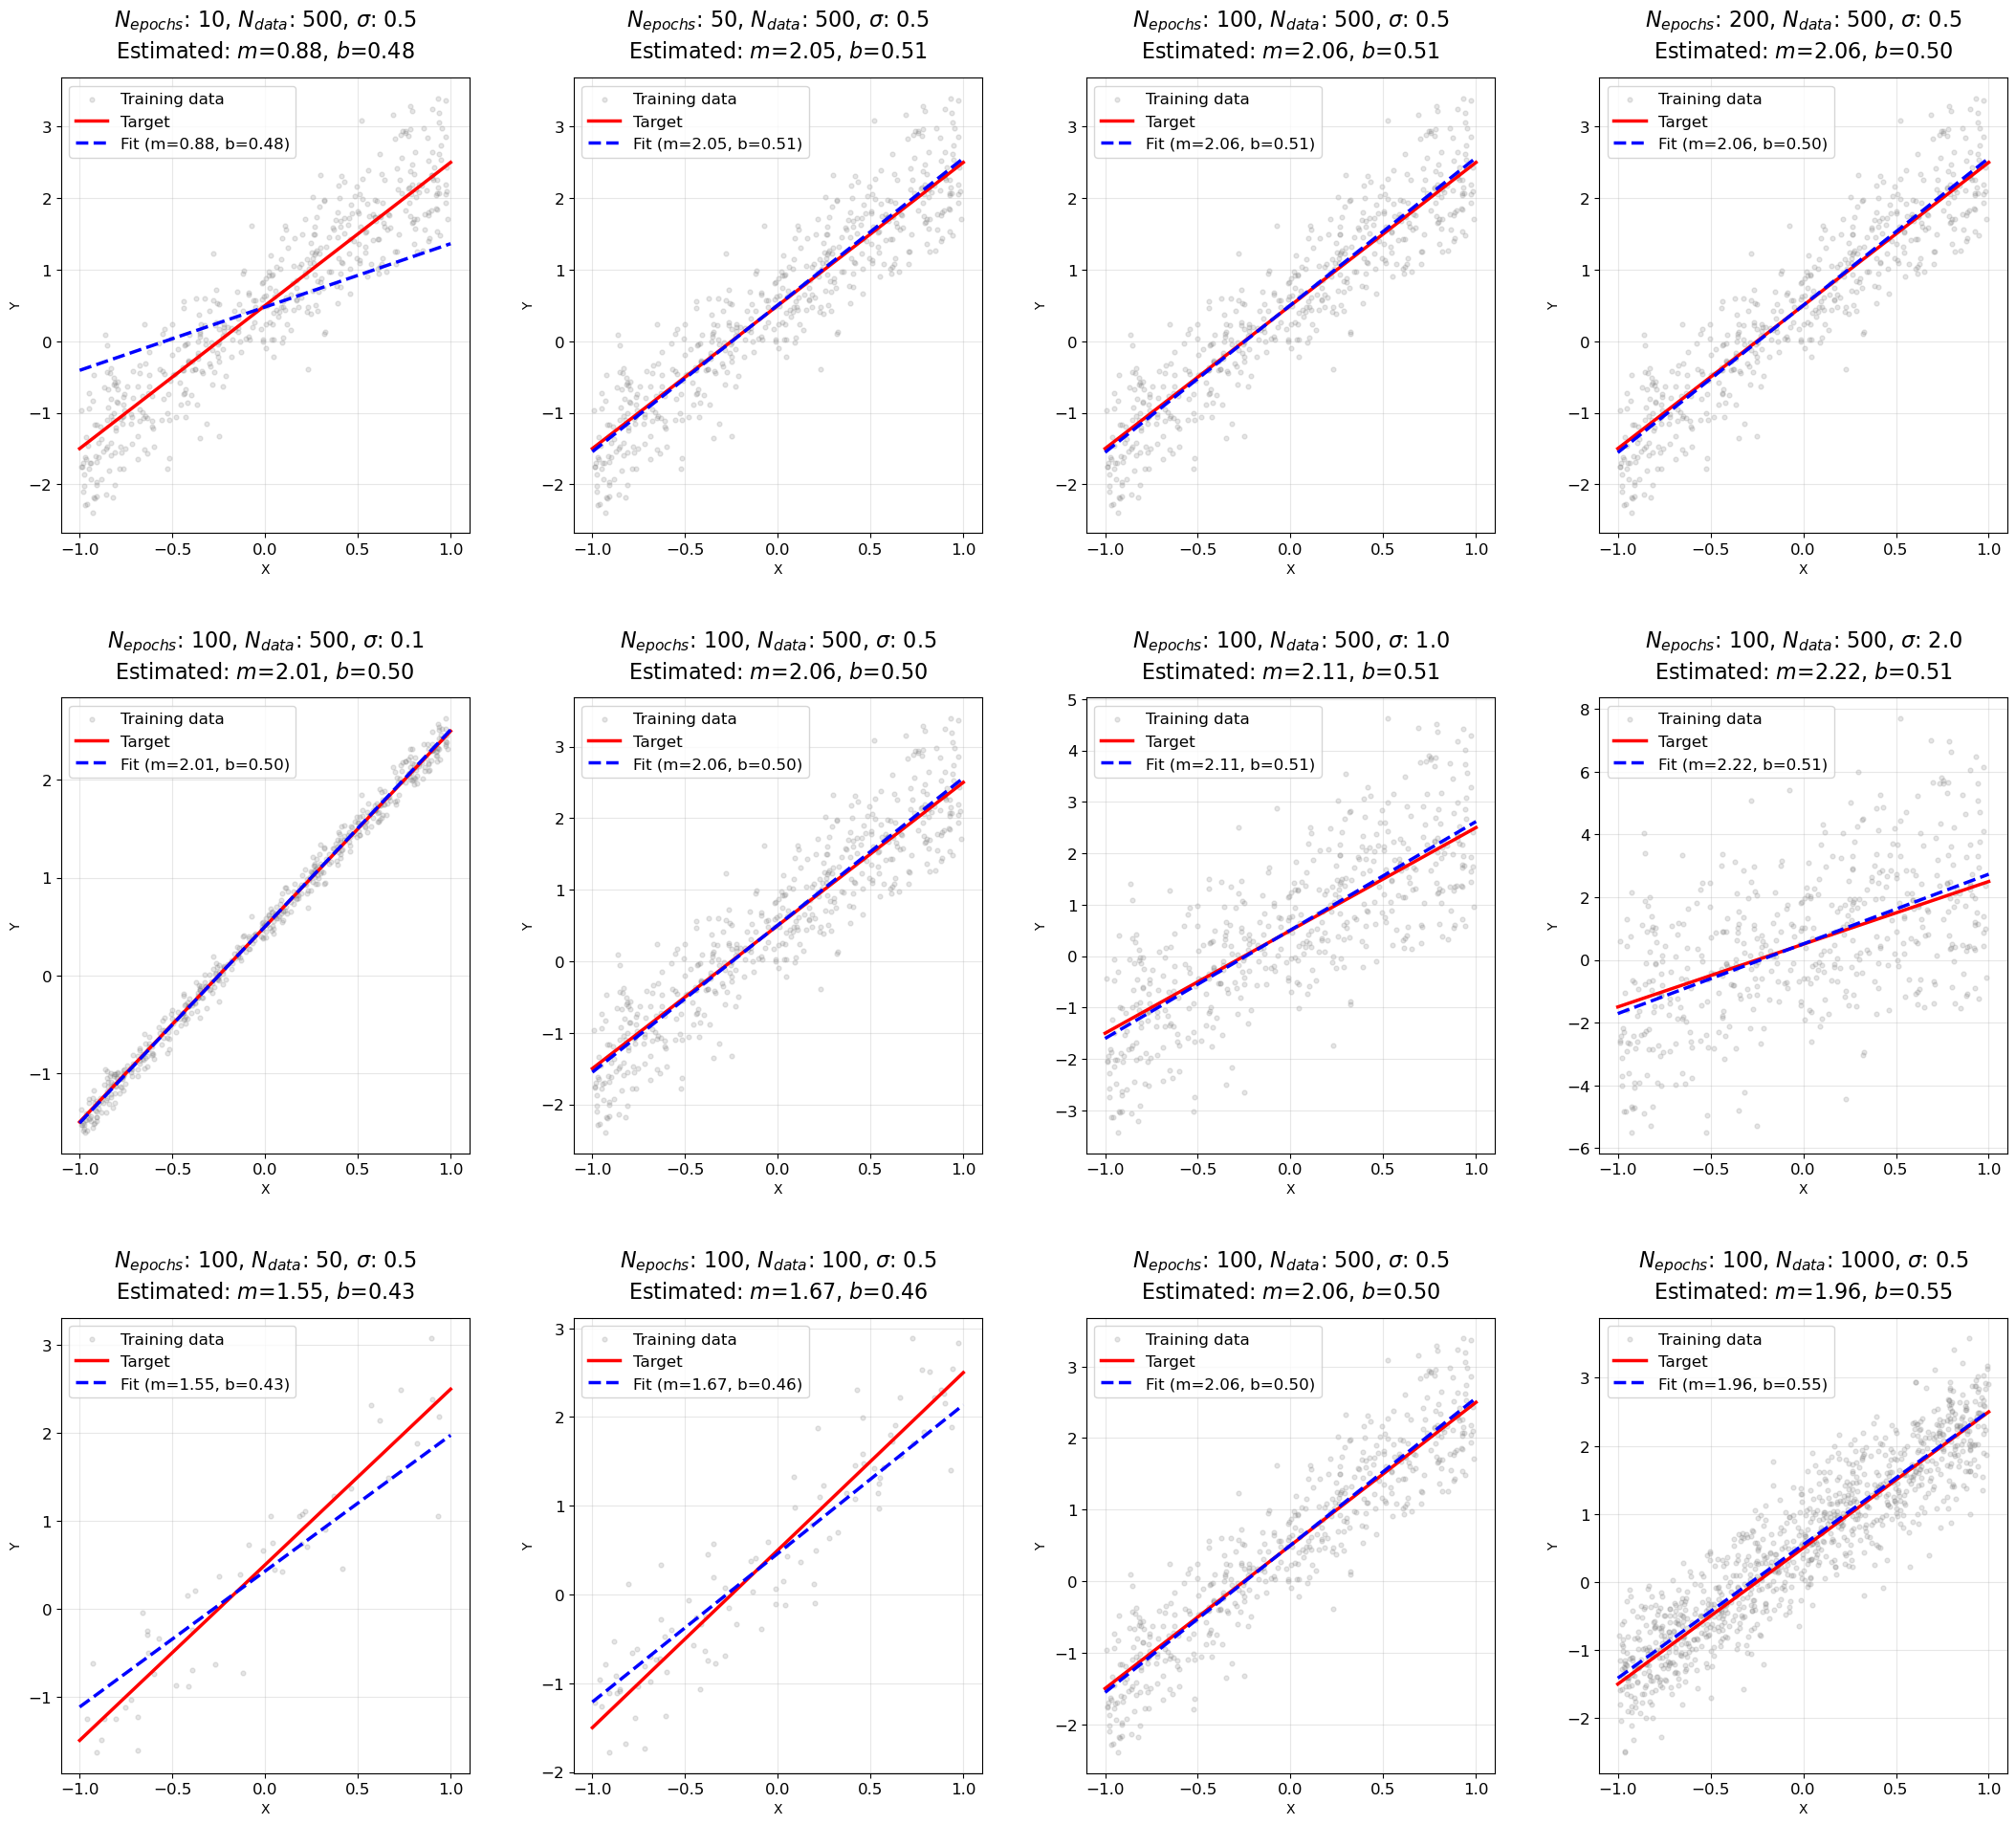

In [35]:
# Aumentata la dimensione della figura per accomodare font più grandi
fig, axes = plt.subplots(3, 4, figsize=(22, 20))
axes = axes.flatten()

x_plot = np.linspace(-1, 1, 100)
y_true_plot = m_true * x_plot + b_true

# Definiamo una dimensione base per i font per cambiarla facilmente
FS_TITLE = 16
FS_LABEL = 14

for i, res in enumerate(results):
    ax = axes[i]
    conf = res['conf']
    x_train, y_train = res['data']
    model = res['model']
    
    weights = model.get_weights()
    m_est = weights[0][0][0] 
    b_est = weights[1][0]  
    
    y_pred = model.predict(x_plot, verbose=0)
    
    ax.scatter(x_train, y_train, alpha=0.2, s=12, label='Training data', color='gray')
    ax.plot(x_plot, y_true_plot, 'r-', lw=2.5, label='Target')
    ax.plot(x_plot, y_pred, 'b--', lw=2.5, label=f'Fit (m={m_est:.2f}, b={b_est:.2f})')
    ax.set_ylabel('Y')
    ax.set_xlabel('X')
    ax.set_title(f"$N_{{epochs}}$: {conf['epochs']}, $N_{{data}}$: {conf['n_train']}, $\sigma$: {conf['sigma']}\n"
                 f"Estimated: $m$={m_est:.2f}, $b$={b_est:.2f}", 
                 fontsize=FS_TITLE, pad=15)
    # Gestione font legenda e tick degli assi
    ax.legend(fontsize=FS_LABEL - 2, loc='upper left')
    ax.tick_params(axis='both', which='major', labelsize=FS_LABEL - 2)
    
    ax.grid(True, alpha=0.3)

plt.tight_layout(pad=4.0)
plt.show()

### Exercise 11.2

Try to extend the model to obtain a reasonable fit of the following polynomial of order 3:

$$
f(x)=4-3x-2x^2+3x^3
$$
for $x \in [-1,1]$.

Find good (& reasonable) choices for:

- the number of layers
- the number of neurons in each layer
- the activation function
- the optimizer
- the loss function
  
Check your NN model by seeing how well your fits predict newly generated test data (including on data outside the range you fit. How well do your NN do on points in the range of $x$ where you trained the model? How about points outside the original training data set? 
Summarize what you have learned about the relationship between model complexity (number of parameters), goodness of fit on training data, and the ability to predict well.

In [16]:
def target_function(x):
    return 4 - 3*x - 2*x**2 + 3*x**3

model = tf.keras.Sequential()
model.add(Dense(10, input_shape=(1,),activation="relu"))
model.add(Dense(60, input_shape=(1,),activation="relu"))
model.add(Dense(10, input_shape=(1,),activation="relu"))
model.add(Dense(1))

model.compile(optimizer='sgd', loss='mse', metrics=['mse'])

model.summary()

/Users/simonemariadipaolo/anaconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_30"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_30 (Dense)                │ (None, 10)             │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 60)             │           660 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 10)             │           610 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,301 (5.08 KB)

 Trainable params: 1,301 (5.08 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
np.random.seed(42)
sigma = 0.3

x_train = np.random.uniform(-1, 1, 1000)
y_train = target_function(x_train) + np.random.normal(0, sigma, 1000)

x_valid = np.linspace(-1, 1, 1000)
y_valid= target_function(x_valid) + np.random.normal(0, sigma, 1000)

history = model.fit(x=x_train, y=y_train,
          batch_size=32, epochs=200,
          shuffle=True,
          validation_data=(x_valid, y_valid))

x_predicted = np.random.uniform(-1, 1, 500)
y_predicted = model.predict(x_predicted)

x_predicted2 = np.random.uniform(-2, 2, 500)
y_predicted2 = model.predict(x_predicted)


Epoch 1/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.5210 - mse: 6.5210 - val_loss: 0.6334 - val_mse: 0.6334
Epoch 2/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5982 - mse: 0.5982 - val_loss: 0.4472 - val_mse: 0.4472
Epoch 3/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4623 - mse: 0.4623 - val_loss: 0.3968 - val_mse: 0.3968
Epoch 4/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3673 - mse: 0.3673 - val_loss: 0.3669 - val_mse: 0.3669
Epoch 5/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3558 - mse: 0.3558 - val_loss: 0.3488 - val_mse: 0.3488
Epoch 6/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3157 - mse: 0.3157 - val_loss: 0.3232 - val_mse: 0.3232
Epoch 7/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2928 - mse: 0.2928 - val_loss: 0.3028 - val_mse: 0.3028
Epoch 8/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2958 - mse: 0.2958 - val_loss: 0.2785 - val_mse: 0.2785
Epoch 9/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.241

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 873us/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 797us/step


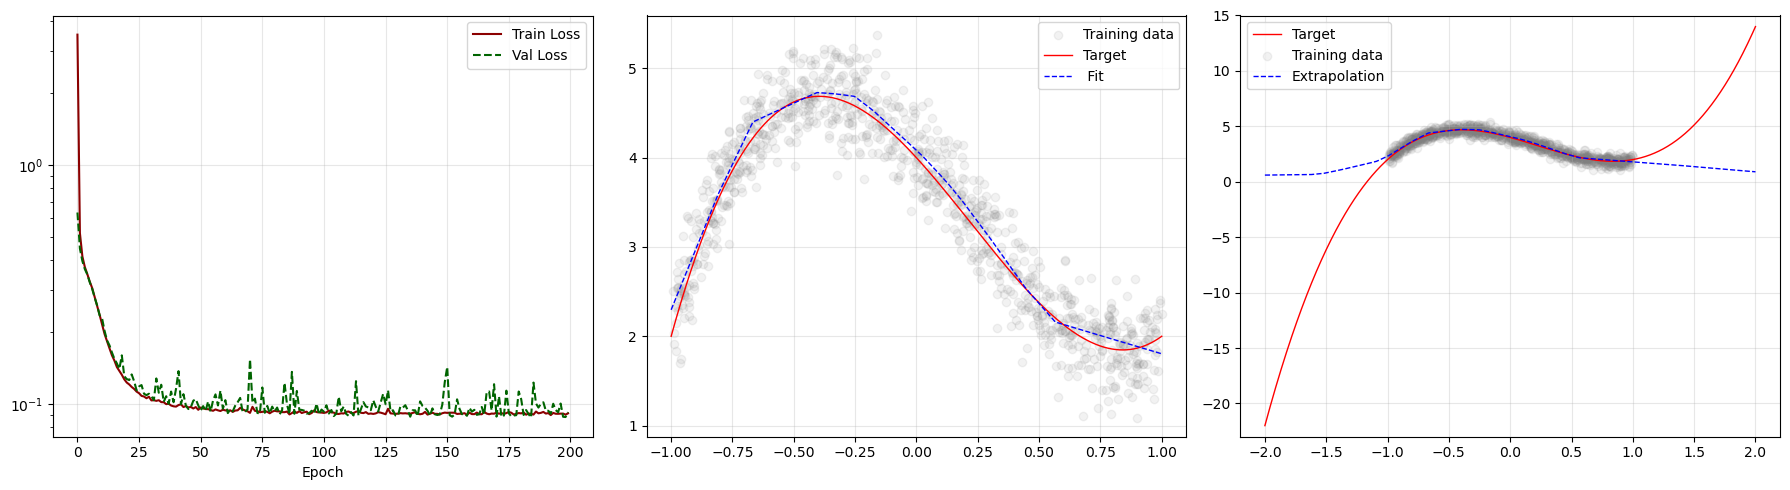

In [18]:
x_test1 = np.linspace(-1, 1, 1000) 
y_pred1 = model.predict(x_test1)

x_test2 = np.linspace(-2, 2, 1000)
y_pred2 = model.predict(x_test2)
y_target_ext = target_function(x_test2)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

ax1.plot(history.history['loss'], label='Train Loss', color='darkred')
ax1.plot(history.history['val_loss'], label='Val Loss', color='darkgreen', linestyle='--')
ax1.set_xlabel("Epoch")
ax1.set_yscale('log')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.scatter(x_train, y_train, alpha=0.1, color='gray', label='Training data')
ax2.plot(x_test1, target_function(x_test1), color='red', lw=1, label='Target')
ax2.plot(x_test1, y_pred1, color='blue', linestyle='--', lw=1, label=' Fit')
ax2.set_xlim([-1.1, 1.1])
ax2.legend()
ax2.grid(True, alpha=0.3)

ax3.plot(x_test2, y_target_ext, color='red', lw=1., label='Target')
ax3.scatter(x_train, y_train, alpha=0.1, color='gray', label='Training data')
ax3.plot(x_test2, y_pred2, color='blue', linestyle='--', lw=1., label='Extrapolation')
ax3.set_ylim([min(y_target_ext)-1, max(y_target_ext)+1])
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Exercise 11.3
  
Try to extend the model to fit a simple trigonometric 2D function such as $f(x,y) = \sin(x^2+y^2)$ in the range $x \in [-3/2,3/2]$ and $y \in [-3/2,3/2]$.

Ideas to meditate on these exercises and judge your results can be found <a href=https://xkcd.com/2048/>here</a>

<>:48: SyntaxWarning: invalid escape sequence '\s'
<>:48: SyntaxWarning: invalid escape sequence '\s'
/var/folders/54/cb99b6bs5m351dkp0hwrqmwr0000gn/T/ipykernel_72944/1988546537.py:48: SyntaxWarning: invalid escape sequence '\s'
  ax2.set_title("Target: $\sin(x^2 + y^2)$")


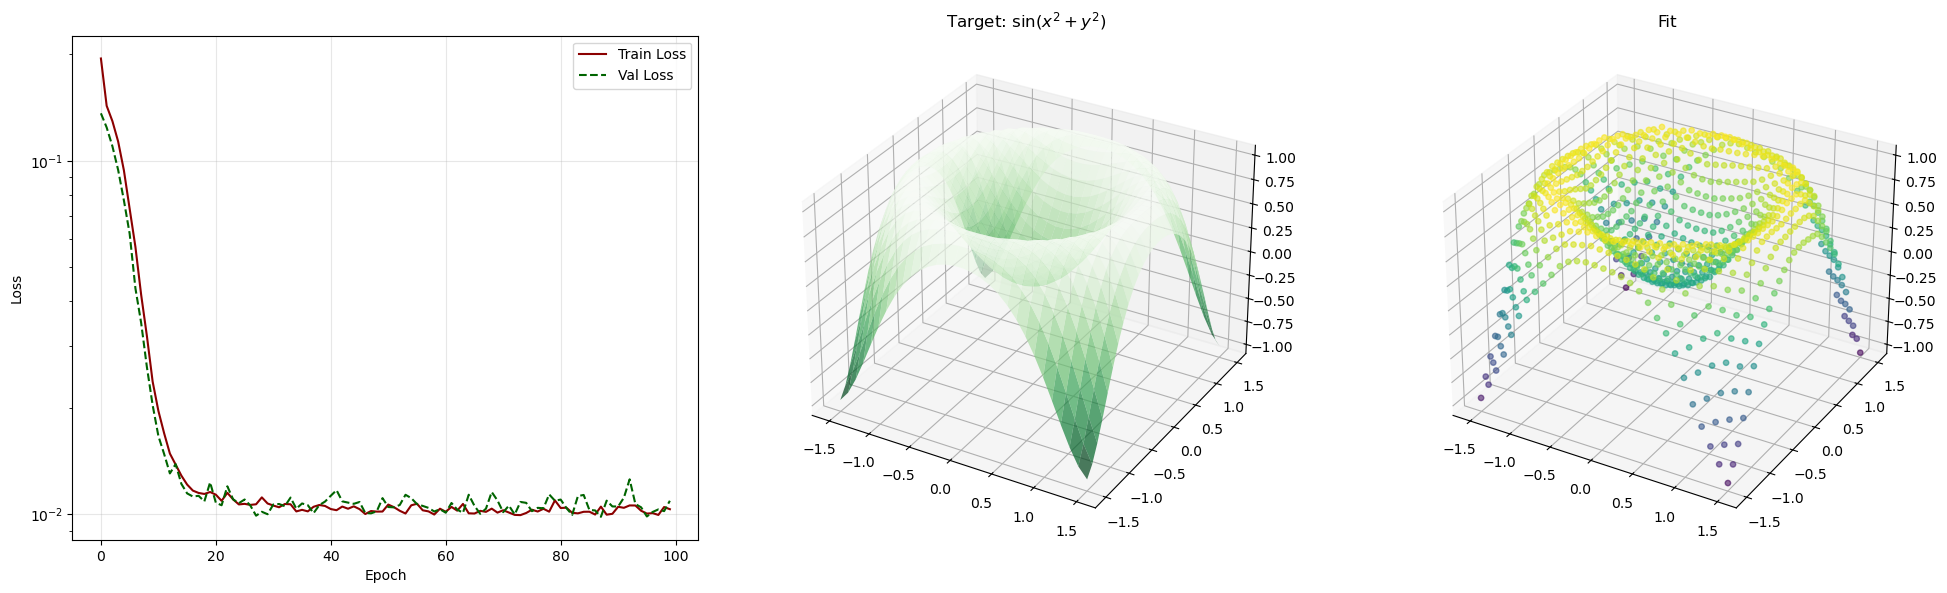

In [19]:
from mpl_toolkits.mplot3d import Axes3D

def target_function(x, y):
    return np.sin(x**2 + y**2)

np.random.seed(42)
n_train = 5000
sigma = 0.1

x_train = np.random.uniform(-1.5, 1.5, n_train)
y_train = np.random.uniform(-1.5, 1.5, n_train)
X_train = np.stack([x_train, y_train], axis=1)
z_train = target_function(x_train, y_train) + np.random.normal(0, sigma, n_train)

grid_size = 30 
x_range = np.linspace(-1.5, 1.5, grid_size)
y_range = np.linspace(-1.5, 1.5, grid_size)
x_grid, y_grid = np.meshgrid(x_range, y_range)
X_plot = np.stack([x_grid.ravel(), y_grid.ravel()], axis=1)
z_true = target_function(x_grid, y_grid)

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(2,)), 
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1, activation='linear') 
])
model.compile(optimizer='adam', loss='mse')

# Training
history = model.fit(X_train, z_train, validation_split=0.2, epochs=100, batch_size=64, verbose=0)

# prediction
z_pred_flat = model.predict(X_plot, verbose=0).flatten()

fig = plt.figure(figsize=(20, 6))
ax1 = fig.add_subplot(1, 3, 1)
ax1.plot(history.history['loss'], label='Train Loss', color='darkred')
ax1.plot(history.history['val_loss'], label='Val Loss', color='darkgreen', linestyle='--')
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_yscale('log')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2 = fig.add_subplot(1, 3, 2, projection='3d')
ax2.plot_surface(x_grid, y_grid, z_true, cmap='Greens_r', antialiased=True, alpha=0.7)
ax2.set_title("Target: $\sin(x^2 + y^2)$")
ax2.set_zlim(-1.1, 1.1)

ax3 = fig.add_subplot(1, 3, 3, projection='3d')
ax3.scatter(X_plot[:, 0], X_plot[:, 1], z_pred_flat, 
            c=z_pred_flat, cmap='viridis', s=15, alpha=0.6)
ax3.set_title("Fit")
ax3.set_zlim(-1.1, 1.1)

plt.tight_layout()
plt.show()

In [24]:
np.random.seed(0)
n_train = 3000
n_valid = 300
sigma = 0.1 

x_train = np.random.uniform(-1.5, 1.5, n_train)
y_train = np.random.uniform(-1.5, 1.5, n_train)
z_train = np.random.normal(np.sin(x_train**2 + y_train**2), sigma)

x_valid = np.random.uniform(-1.5, 1.5, n_valid)
y_valid = np.random.uniform(-1.5, 1.5, n_valid)

x_valid.sort()
y_valid.sort()
z_valid = np.random.normal(np.sin(x_valid**2 + y_valid**2), sigma)

X_surf = np.linspace(-1.5, 1.5, 100)
Y_surf = np.linspace(-1.5, 1.5, 100)
X_surf, Y_surf = np.meshgrid(X_surf, Y_surf)
Z_target = np.sin(X_surf**2 + Y_surf**2)

model = Sequential()
model.add(Dense(16, activation='tanh', input_shape=(2,))) # 1st layer
model.add(Dense(32, activation='tanh'))                   # Hidden layer 1
model.add(Dense(64, activation='tanh'))                   # Hidden layer 2
model.add(Dense(1))                                       # Output layer

model.compile(optimizer='adam', loss='mse', metrics=['mse'])
model.summary()

history = model.fit(
    x = np.column_stack((x_train, y_train)), 
    y = z_train,
    batch_size=32, 
    epochs=250,
    shuffle=True, 
    validation_data=(np.column_stack((x_valid, y_valid)), z_valid),
    verbose=1
)

Model: "sequential_35"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_49 (Dense)                │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_51 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_52 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,769 (10.82 KB)

 Trainable params: 2,769 (10.82 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/250
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3013 - mse: 0.3013 - val_loss: 0.3521 - val_mse: 0.3521
Epoch 2/250
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1735 - mse: 0.1735 - val_loss: 0.3748 - val_mse: 0.3748
Epoch 3/250
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1753 - mse: 0.1753 - val_loss: 0.3929 - val_mse: 0.3929
Epoch 4/250
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1584 - mse: 0.1584 - val_loss: 0.3787 - val_mse: 0.3787
Epoch 5/250
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1691 - mse: 0.1691 - val_loss: 0.3627 - val_mse: 0.3627
Epoch 6/250
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1639 - mse: 0.1639 - val_loss: 0.3469 - val_mse: 0.3469
Epoch 7/250
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1648 - mse: 0.1648 - val_loss: 0.3443 - val_mse: 0.3443
Epoch 8/250
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1614 - mse: 0.1614 - val_loss: 0.3684 - val_mse: 0.3684
Epoch 9/250
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.169


Test loss: 0.01094080787152052
Test MSE: 0.01094080787152052
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


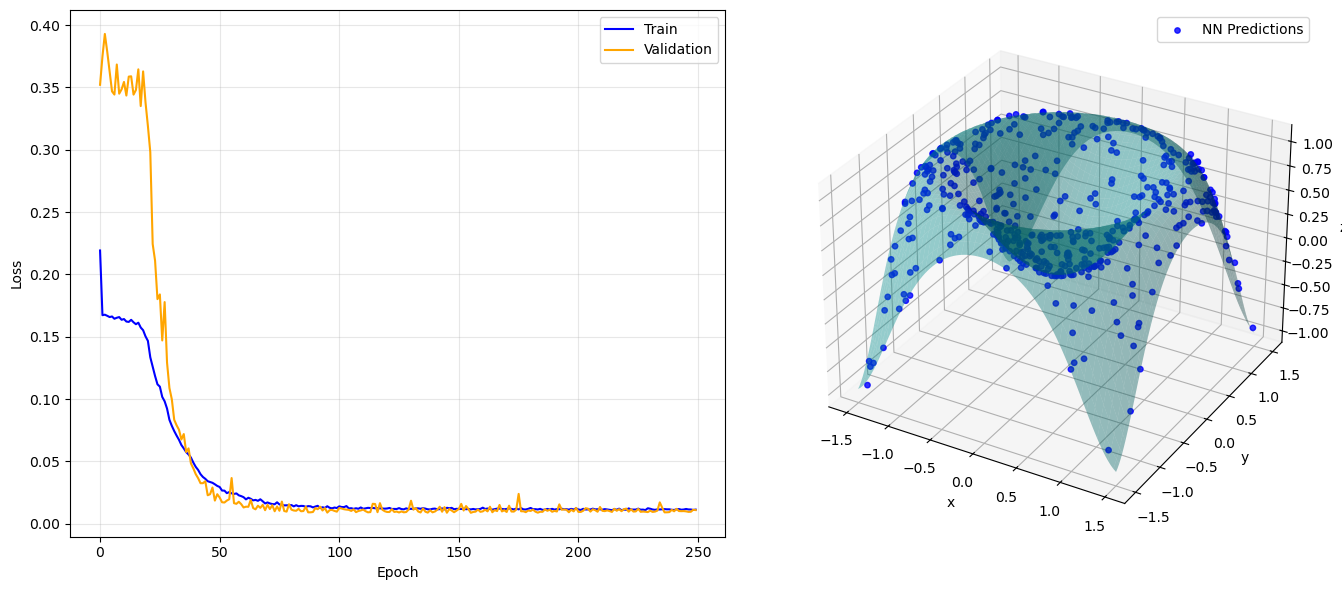

In [25]:
score = model.evaluate(np.column_stack((x_valid, y_valid)), z_valid, batch_size=32, verbose=0)
print(f'\nTest loss: {score[0]}')
print(f'Test MSE: {score[1]}')

x_predicted = np.random.uniform(-1.5, 1.5, 500)
y_predicted = np.random.uniform(-1.5, 1.5, 500)
z_predicted = model.predict(np.column_stack((x_predicted, y_predicted))).flatten()

fig = plt.figure(figsize=(14, 6))

ax1 = fig.add_subplot(121)
ax1.plot(history.history['loss'], label='Train', color='blue')
ax1.plot(history.history['val_loss'], label='Validation', color='orange')
ax1.set_ylabel('Loss')
ax1.set_xlabel('Epoch')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(X_surf, Y_surf, Z_target, color='darkcyan', edgecolor='none', alpha=0.4)
ax2.scatter(x_predicted, y_predicted, z_predicted, 
            color='blue', s=15, alpha=0.8, label='NN Predictions')

ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_zlabel('z')
ax2.legend()

plt.tight_layout()
plt.show()